# Predicting Patient-Level Outcomes in Colon Cancer Using Genomic and Clinical Data

The objective of this project is to predict patient-level outcomes, such as survival rates or likelihood of recurrence, using genomic and clinical data from colon cancer patients, while leveraging neural networks for machine learning.

The goals of this project are to:
- Build a predictive model for a defined outcome (e.g., binary survival classification: survived beyond 5 years vs. not).
- Explore the impact of different data types (genomic vs. clinical) on model performance.
- Learn about neural networks and how they are utilized in ML.

Data was found on this website: https://portal.gdc.cancer.gov/projects/TCGA-COAD

Below are the libraries required for this project.

## Data Manipulation & Visualization

**pandas (import pandas as pd)**
Used for data manipulation and analysis through creating data structures 

**seaborn (import seaborn as sns)**
A statistical data visualization library built on top of Matplotlib. 

**matplotlib.pyplot (import matplotlib.pyplot as plt)**
A low-level library for creating static, animated, and interactive visualizations in Python. It allows for detailed customization of plots.

### Deep Learning with TensorFlow/Keras

**tensorflow.keras.models.Sequential**
allows building deep learning models layer by layer in a linear stack.

**tensorflow.keras.layers.Dense**
A fully connected (dense) layer in a neural network, where each neuron is connected to every neuron in the previous layer.

**tensorflow.keras.layers.Dropout**
A regularization technique that randomly drops a fraction of neurons during training to prevent overfitting.

### Machine Learning Utilities
**sklearn.model_selection.train_test_split**
Splits the dataset into training and testing (or validation) subsets to evaluate model performance.

**sklearn.metrics.classification_report**
Generates a detailed performance report for classification models, including precision, recall, F1-score, and support.

**sklearn.metrics.confusion_matrix**
Computes a matrix that shows the number of correct and incorrect predictions for each class in a classification task.

**sklearn.preprocessing.StandardScaler**
Standardizes numerical data by transforming features to have a mean of 0 and a standard deviation of 1, improving model performance.

**sklearn.preprocessing.LabelEncoder**
Encodes categorical labels into numerical values (e.g., "Male" → 0, "Female" → 1) for machine learning models that require numeric input.


In [ ]:
# -*- coding: utf-8 -*-

#import libraries
import pandas                as pd
import seaborn               as sns
import matplotlib.pyplot     as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics         import classification_report, confusion_matrix
from sklearn.preprocessing   import StandardScaler
from sklearn.preprocessing   import LabelEncoder

In [ ]:
# load dataset
col_names = ['case_id',
             'aliquot_quantity',
             'aliquot_volume', 
             'concentration', 
             'age_at_index', 
             'ethnicity', 
             'gender', 
             'race', 
             'vital_status', 
             'year_of_birth', 
             'age_at_diagnosis_adj', 
             'ajcc_pathologic_m', 
             'ajcc_pathologic_n', 
             'ajcc_pathologic_stage', 
             'ajcc_pathologic_t', 
             'ajcc_staging_system_edition', 
             'days_to_last_follow_up', 
             'icd_10_code', 
             'morphology', 
             'primary_diagnosis', 
             'prior_malignancy', 
             'prior_treatment', 
             'progression_or_recurrence', 
             'site_of_resection_or_biopsy', 
             'synchronous_malignancy', 
             'tissue_or_organ_of_origin', 
             'year_of_diagnosis', 
             'treatment_or_therapy', 
             'treatment_type'
             ]
data = pd.read_csv("clinical.csv", header=0, names=col_names)
data["days_to_last_follow_up"] = [float(str(i).replace(",", "")) for i in data["days_to_last_follow_up"]]

In [ ]:
#convert data types
new_types = {
    'case_id'                       : 'string',
    'aliquot_quantity'              : 'float',
    'aliquot_volume'                : 'float', 
    'concentration'                 : 'float', 
    'age_at_index'                  : 'int',
    'ethnicity'                     : 'category', 
    'gender'                        : 'category', 
    'race'                          : 'category', 
    'vital_status'                  : 'category', 
    'year_of_birth'                 : 'int',
    'age_at_diagnosis_adj'          : 'float',
    'ajcc_pathologic_m'             : 'category', 
    'ajcc_pathologic_n'             : 'category',  
    'ajcc_pathologic_stage'         : 'category',  
    'ajcc_pathologic_t'             : 'category', 
    'ajcc_staging_system_edition'   : 'category', 
    'days_to_last_follow_up'        : 'int',
    'icd_10_code'                   : 'category', 
    'morphology'                    : 'category', 
    'primary_diagnosis'             : 'category', 
    'prior_malignancy'              : 'category', 
    'prior_treatment'               : 'category',  
    'site_of_resection_or_biopsy'   : 'category',  
    'synchronous_malignancy'        : 'category', 
    'tissue_or_organ_of_origin'     : 'category',  
    'year_of_diagnosis'             : 'int',
    'treatment_or_therapy'          : 'category',  
    'treatment_type'                : 'category'
    }

data = data.astype(new_types)

#encode categorical variables
label_encoder = LabelEncoder()
for column in ['ethnicity', 
               'gender', 
               'race', 
               'vital_status', 
               'ajcc_pathologic_m', 
               'ajcc_pathologic_n',
               'ajcc_pathologic_stage', 
               'ajcc_pathologic_t', 
               'ajcc_staging_system_edition', 
               'icd_10_code', 
               'morphology', 
               'primary_diagnosis', 
               'prior_malignancy', 
               'prior_treatment', 
               'site_of_resection_or_biopsy', 
               'synchronous_malignancy', 
               'tissue_or_organ_of_origin', 
               'treatment_or_therapy',
               'treatment_type'
               ]:
    data[column] = label_encoder.fit_transform(data[column])
    
data = data.dropna().reset_index(drop=True)

In [ ]:
#split dataset in features and target variable
feature_cols = ['aliquot_quantity',
             'aliquot_volume', 
             'concentration', 
             'gender', 
             'race', 
             'year_of_birth', 
             # 'age_at_diagnosis_adj', 
             # 'ajcc_pathologic_m', 
             'ajcc_pathologic_n', 
             # 'ajcc_pathologic_stage', 
             # 'ajcc_pathologic_t', 
             # 'ajcc_staging_system_edition', 
             # 'days_to_last_follow_up', 
             # 'icd_10_code', 
             # 'primary_diagnosis', 
             # 'prior_malignancy', 
             'prior_treatment', 
             'site_of_resection_or_biopsy', 
             # 'synchronous_malignancy', 
             # 'tissue_or_organ_of_origin', 
             # 'year_of_diagnosis', 
             # 'treatment_or_therapy', 
             # 'treatment_type'
             ]
# columns were dropped due to model becoming too accurate and therefore unrealistic

X = data[feature_cols].reset_index(drop=True)  # Feature variables
y = data.vital_status.reset_index(drop=True)   # Target variable

X = X.loc[y.index]
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

### Further Data Processing

**SMOTE**

SMOTE stands for Synthetic Minority Over-sampling Technique. It's a method used to address class imbalance in classification problems.

Why is Class Imbalance a Problem?
If one class (e.g., "cancer recurrence") is much less common than another (e.g., "no recurrence"), a model might bias toward predicting the majority class, leading to poor performance for the minority class.

For example:

Actual Labels: 90% Class 0, 10% Class 1

A model could achieve 90% accuracy by predicting only Class 0, but it wouldn't learn anything meaningful about Class 1.

SMOTE was added in later iterations of the test to address oversampling and accuracy issues.


In [ ]:
#resample: Use oversampling (SMOTE) to balance the classes:

from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X, y  = smote.fit_resample(X, y)

#split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# Create a heatmap to check for multicollinearity
feature_names = X.columns
data_df       = pd.DataFrame(X, columns=feature_names)
corr_matrix   = data_df.corr()

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", annot_kws={"size": 10}, xticklabels=feature_names, yticklabels=feature_names)
plt.gcf().set_size_inches(20, 16)
plt.title("Feature Correlation Heatmap")
plt.show()

### Building the Neural Network

**What is a neural network?**

A neural network is a machine learning model inspired by how the human brain processes information. It’s made up of layers of interconnected nodes (called neurons) that learn to recognize patterns in data.

In this case, the model's job is to learn which patterns in the genomic and clinical data are associated with a patient outcome — like whether the patient survives or not — and then use those patterns to make predictions.

**Stacked Linear Model**

A stacked linear model means each layer feeds directly into the next — a simple "stack" of layers. Below is the list of layers that are used in this model.

## What Is a Node (Neuron) in a Neural Network?

A **node** (or **neuron**) is a single computational unit that:
1. **Receives input(s)** from other neurons (or from raw input features),
2. **Applies a weighted sum** to those inputs,
3. **Adds a bias**,
4. **Applies an activation function** to decide what signal to pass to the next layer.


## How Neurons Work Together in a Layer

Each layer has multiple neurons, and **each one is learning a different "view" or feature** of the input data.

- For example, in a layer with 32 neurons:
  - Neuron 1 might detect patterns involving age and tumor size.
  - Neuron 2 might focus on a specific gene expression level.
  - Neuron 3 might combine demographic info with survival outcome.
  - All 32 compute independently and send their results to the next layer.



| Layer   | Type  | Units | Activation | Notes                          |
| ------- | ----- | ----- | ---------- | ------------------------------ |
| Input   | Dense | 32    | ReLU       | Accepts feature vector         |
| Dropout | -     | 30%   | -          | Prevents overfitting           |
| Hidden  | Dense | 16    | ReLU       | Further feature transformation |
| Dropout | -     | 30%   | -          | More regularization            |
| Output  | Dense | 1     | Sigmoid    | Outputs a probability (0 to 1) |


Some terminology in explaining these layers:

**Input Layer**
Dense: A fully connected layer — every neuron in this layer receives input from every feature (column) in your dataset.

32 Units: Each neuron learns a different pattern in the data.

activation='relu': ReLU (Rectified Linear Unit) introduces non-linearity.

Purpose: Learn 32 different patterns or "rules" from the data.

Dropout randomly "turns off" 30% of the neurons in the previous layer during training. This forces the model to not rely too heavily on specific neurons, which helps reduce overfitting.

**Hidden Layer**

This is another fully connected layer, this time with 16 neurons. This layer takes the outputs of the first layer and combines them in new ways to learn higher-level features.


**Output Layer**

This is the final decision-making layer.

Only 1 neuron is needed because you're doing binary classification (e.g., survived = 1, didn’t survive = 0).

Sigmoid activation turns the result into a probability between 0 and 1:

0.5 → Class 1 (e.g., survived)

≤ 0.5 → Class 0 (e.g., not survived)

0       0
1       0
2       0
3       0
4       0
       ..
8150    0
8151    0
8152    0
8153    0
8154    0
Name: vital_status, Length: 8155, dtype: int32


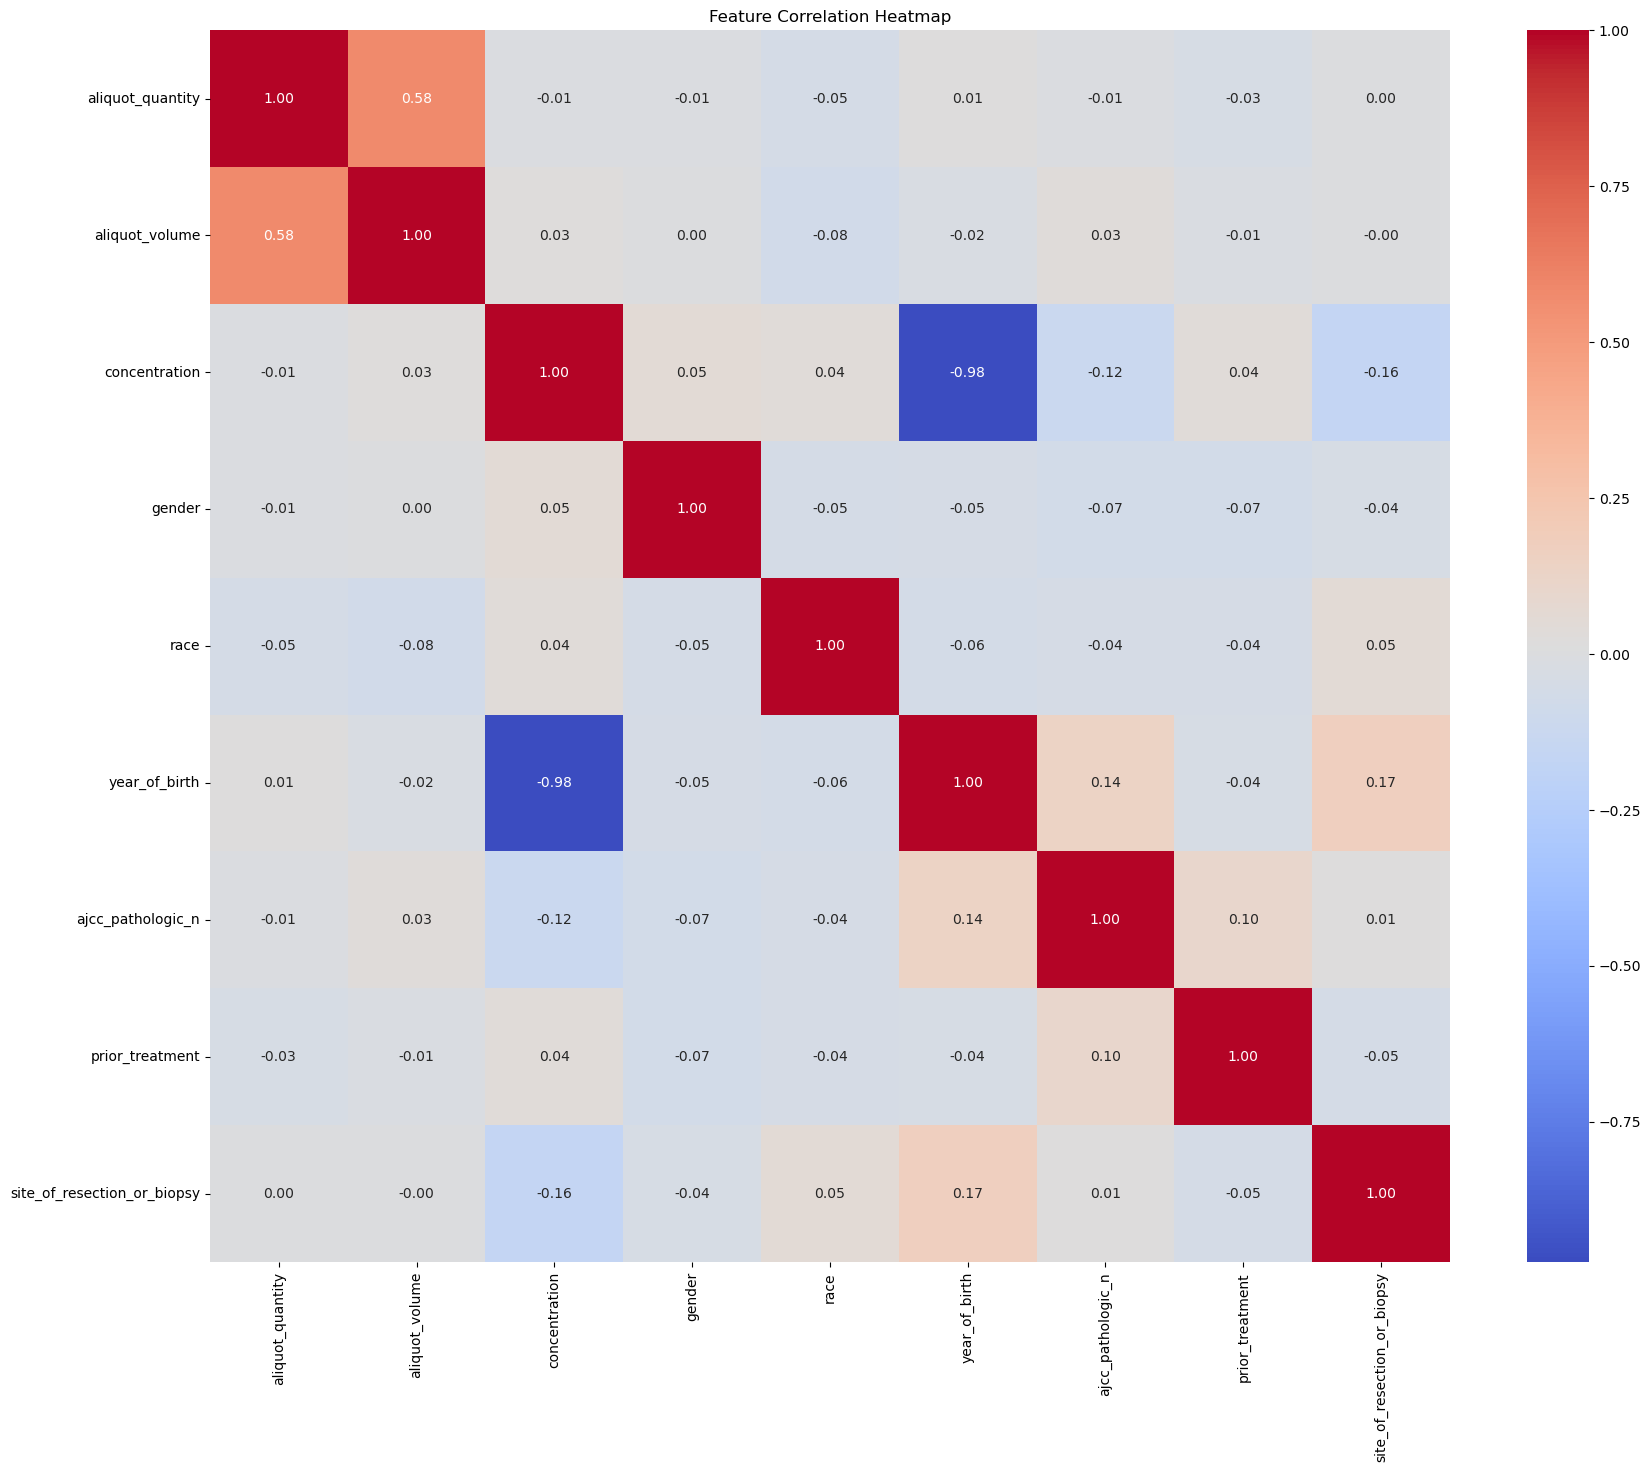

C:\Users\Shuu\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5638 - loss: 0.6840 - val_accuracy: 0.6540 - val_loss: 0.6250
Epoch 2/50
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 946us/step - accuracy: 0.6564 - loss: 0.6284 - val_accuracy: 0.6788 - val_loss: 0.6012
Epoch 3/50
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 995us/step - accuracy: 0.6668 - loss: 0.6168 - val_accuracy: 0.6725 - val_loss: 0.5897
Epoch 4/50
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6629 - loss: 0.6106 - val_accuracy: 0.7066 - val_loss: 0.5791
Epoch 5/50
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 945us/step - accuracy: 0.6815 - loss: 0.5946 - val_accuracy: 0.7178 - val_loss: 0.5698
Epoch 6/50
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 924us/step - accuracy: 0.6879 - loss: 0.5980 - val_accuracy: 0.7061 - val_loss: 0.5628
Epoch 7/50
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 897us/step - accuracy: 0.7020 - loss: 0.5846 - val_accuracy: 0.7115 - val_loss: 0.5569
Epoch 8/50
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 935us/step - accuracy: 0.6965 - loss: 0.5739 - val_

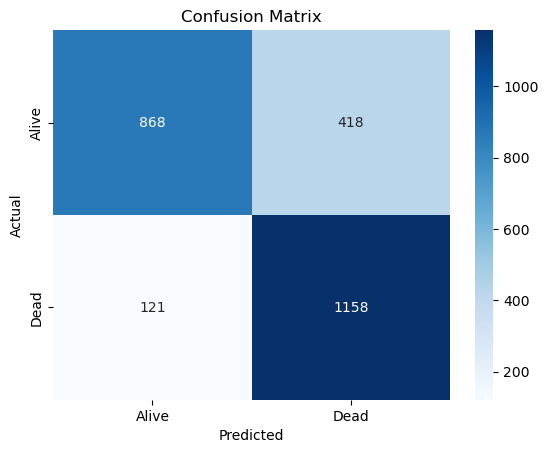

In [ ]:
# Build the neural network model
# Add dropout layers to prevent the model from overfitting
model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
# Add early stopping: stops training when validation performance stops improving:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, callbacks=[early_stopping])

# Evaluate the model
eval_results = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {eval_results[0]:.4f}, Test Accuracy: {eval_results[1]:.4f}")

# Predictions and classification report
predictions = (model.predict(X_test) > 0.5).astype(int).flatten()
print("Classification Report:")
print(classification_report(y_test, predictions))

# Confusion matrix
conf_matrix = confusion_matrix(y_test, predictions)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Alive", "Dead"], yticklabels=["Alive", "Dead"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()